# Audit Machine Learning: Prediksi Kelulusan Mahasiswa
**Notebook Audit & Eksperimen Pipeline MLOps**

Notebook ini berfungsi sebagai driver eksperimental yang selaras dengan modul `src/`. Semua logika di sini mengikuti standar audit akademik yang ketat (Zero Data Leakage, Transparent Feature Selection, dan Optimized Hyperparameters).

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Konfigurasi Path
DATA_PATH = '../data/raw/student_dropout_prediction.csv'
OUTPUT_DIR = '../outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✅ Library dan Environment Berhasil Disiapkan.")

✅ Library dan Environment Berhasil Disiapkan.


### Fase 1: Data Loading & Audit Awal
Melakukan pembersihan nama kolom, deteksi tipe data, dan analisis korelasi fitur.

[*] Audit Report: 4424 baris, 35 kolom.
[*] Missing Values: 0
[*] Duplikat: 0


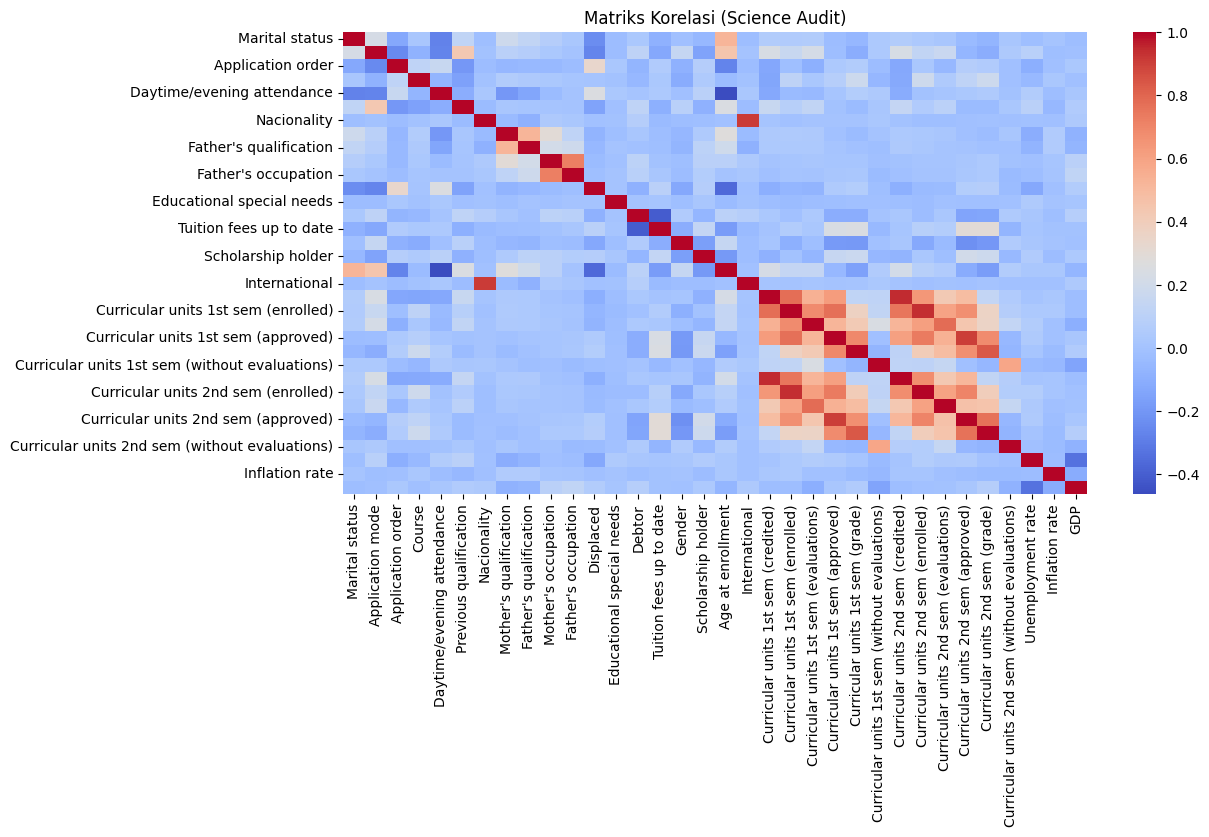

In [2]:
def load_and_audit(path):
    # 1. Load dengan auto-separator
    try:
        df = pd.read_csv(path, sep=';')
        if len(df.columns) < 2: df = pd.read_csv(path, sep=',')
    except:
        df = pd.read_csv(path)
        
    # 2. Cleaning
    df.columns = [c.strip() for c in df.columns]
    
    # 3. Numeric Coercion (Handling Messy Data)
    for col in df.columns:
        if col.lower() not in ['target', 'status']:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            
    print(f"[*] Audit Report: {df.shape[0]} baris, {df.shape[1]} kolom.")
    print(f"[*] Missing Values: {df.isnull().sum().sum()}")
    print(f"[*] Duplikat: {df.duplicated().sum()}")
    
    # Heatmap Korelasi
    plt.figure(figsize=(12, 6))
    sns.heatmap(df.select_dtypes(include=[np.number]).corr(), cmap='coolwarm', annot=False)
    plt.title("Matriks Korelasi (Science Audit)")
    plt.show()
    
    return df

df_raw = load_and_audit(DATA_PATH)

### Fase 2: Data Preparation (Preprocessing)
Implementasi Median/Mode Imputation, IQR Clipping (Outlier), dan Target Encoding.

In [3]:
def preprocess_data(df):
    df = df.drop_duplicates().reset_index(drop=True)
    
    # 1. Target Encoding (Multi-class)
    le = LabelEncoder()
    df['Target'] = le.fit_transform(df['Target'])
    print(f"[*] Target Mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")
    
    # 2. Imputation
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df.select_dtypes(include=['object']).columns.tolist()
    
    df[num_cols] = SimpleImputer(strategy='median').fit_transform(df[num_cols])
    if cat_cols:
        df[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(df[cat_cols])
    
    # 3. IQR Clipping (Outlier Handling)
    for col in [c for c in num_cols if c != 'Target']:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        df[col] = np.clip(df[col], Q1 - 1.5*IQR, Q3 + 1.5*IQR)
        
    # 4. Split
    X = df.drop(['Target'], axis=1)
    y = df['Target']
    
    # Drop ID
    for c in ['student_id', 'id', 'STUDENT_ID']: 
        if c in X.columns: X = X.drop(c, axis=1)
        
    return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_test, y_train, y_test = preprocess_data(df_raw)
print(f"✅ Split Selesai: Train ({len(X_train)}), Test ({len(X_test)})")

[*] Target Mapping: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}
✅ Split Selesai: Train (3539), Test (885)


### Fase 3: Feature Engineering
Transformasi kategorikal (OHE), Scaling, dan Seleksi Fitur Utama.

In [4]:
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()

ct = ColumnTransformer([
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_features)
], remainder='passthrough')

X_train_t = ct.fit_transform(X_train)
X_test_t = ct.transform(X_test)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_t)
X_test_s = scaler.transform(X_test_t)

# Seleksi 30 Fitur Terbaik
selector = SelectKBest(f_classif, k=min(30, X_train_s.shape[1]))
X_train_final = selector.fit_transform(X_train_s, y_train)
X_test_final = selector.transform(X_test_s)

print(f"✅ Feature Engineering Selesai. Dimensi Akhir: {X_train_final.shape[1]} fitur.")

✅ Feature Engineering Selesai. Dimensi Akhir: 30 fitur.


C:\Users\Bella\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [ 0  4  5  6 12 13 14 16 18 19 24 25 30] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\Bella\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


### Fase 4: Modeling (SMOTE & Hyperparameter Tuning)
Melatih 3 model (RF, XGB, GB) dengan pencarian parameter optimal.

In [5]:
print("[*] Menjalankan SMOTE untuk penyeimbangan data...")
smote = SMOTE(random_state=42)
resampled = smote.fit_resample(X_train_final, y_train)
X_res, y_res = resampled[0], resampled[1]

models = {
    "Random Forest": (RandomForestClassifier(random_state=42), 
                      {'n_estimators': [100, 200], 'max_depth': [None, 10]}),
    "XGBoost": (XGBClassifier(eval_metric='logloss', random_state=42), 
                {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1]}),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=42), 
                          {'n_estimators': [100], 'learning_rate': [0.05, 0.1]})
}

best_models = {}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for name, (model, params) in models.items():
    print(f"[*] Tuning {name}...")
    search = RandomizedSearchCV(model, params, n_iter=5, cv=cv, scoring='accuracy', random_state=42)
    search.fit(X_res, y_res)
    best_models[name] = search.best_estimator_
    print(f"    Best Score: {search.best_score_:.4f}")

print("✅ Training Selesai.")

[*] Menjalankan SMOTE untuk penyeimbangan data...
[*] Tuning Random Forest...


C:\Users\Bella\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


    Best Score: 0.8189
[*] Tuning XGBoost...


C:\Users\Bella\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


    Best Score: 0.8144
[*] Tuning Gradient Boosting...


C:\Users\Bella\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 2 is smaller than n_iter=5. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


    Best Score: 0.7765
✅ Training Selesai.


### Fase 5: Evaluasi & Audit Hasil
Melihat performa model pada data testing dan confusion matrix.


--- Evaluasi Random Forest ---
Accuracy: 0.7401
              precision    recall  f1-score   support

         0.0       0.80      0.70      0.75       284
         1.0       0.44      0.47      0.45       159
         2.0       0.81      0.87      0.84       442

    accuracy                           0.74       885
   macro avg       0.69      0.68      0.68       885
weighted avg       0.74      0.74      0.74       885



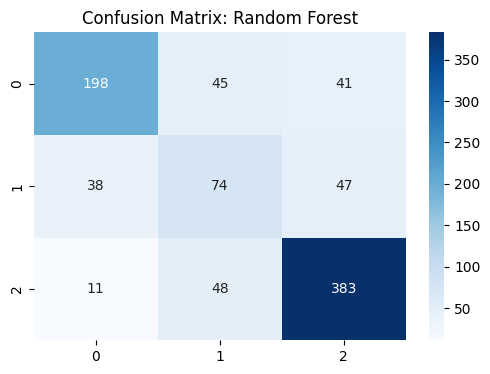


--- Evaluasi XGBoost ---
Accuracy: 0.7424
              precision    recall  f1-score   support

         0.0       0.77      0.71      0.74       284
         1.0       0.46      0.45      0.46       159
         2.0       0.82      0.87      0.84       442

    accuracy                           0.74       885
   macro avg       0.68      0.68      0.68       885
weighted avg       0.74      0.74      0.74       885



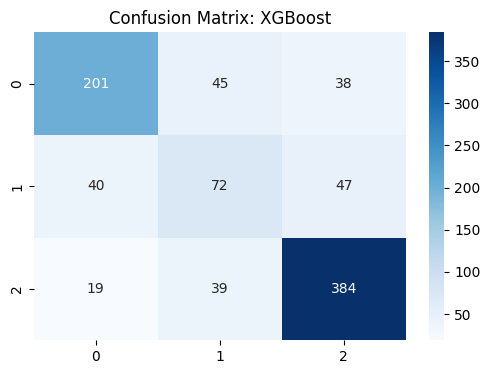


--- Evaluasi Gradient Boosting ---
Accuracy: 0.7480
              precision    recall  f1-score   support

         0.0       0.76      0.73      0.74       284
         1.0       0.48      0.50      0.49       159
         2.0       0.84      0.85      0.84       442

    accuracy                           0.75       885
   macro avg       0.69      0.69      0.69       885
weighted avg       0.75      0.75      0.75       885



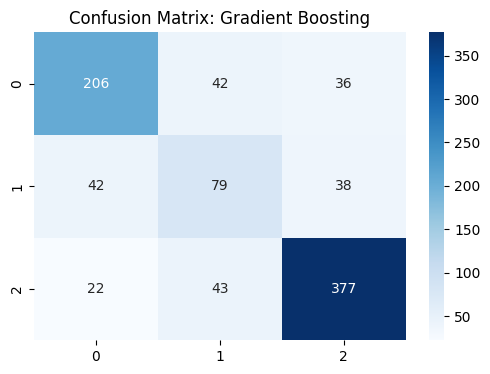

In [6]:
for name, model in best_models.items():
    y_pred = model.predict(X_test_final)
    print(f"\n--- Evaluasi {name} ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))
    
    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {name}")
    plt.show()